# SOP pretrained reproduction

This notebook runs the unified DeepACO reproduction entry point for this problem. It writes logs, raw JSON, Markdown tables, and PNG figures to the repository-level output folders.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'pretrained').exists() else cwd.parent
sys.path.insert(0, str(ROOT))

from scripts.reproduce_problem import run_problem

PROBLEM = 'sop'
DEVICE = 'auto'          # 'auto', 'cpu', 'cuda', or 'cuda:0'
SEED = 12345
LIMIT_INSTANCES = None   # set to a small integer for a quick smoke test
SIZES = None             # e.g. [20] or None for all configured scales
T_ACO = None             # e.g. [1, 10] or None for paper-style checkpoints
METHODS = None           # e.g. ['deepaco'] or ['deepaco', 'aco']
INCLUDE_BASELINE = True


e:\DeepAoc\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw = run_problem(
    PROBLEM,
    sizes=SIZES,
    t_aco=T_ACO,
    methods=METHODS,
    limit_instances=LIMIT_INSTANCES,
    device=DEVICE,
    seed=SEED,
    include_baseline=INCLUDE_BASELINE,
)
raw['outputs']


[2026-05-10T17:10:01] Starting SOP reproduction
[2026-05-10T17:10:01] sizes=[20, 50, 100], t_aco=[1, 10, 20, 30, 40, 50, 100], methods=['deepaco', 'aco'], device=cpu
[2026-05-10T17:10:02] SOP20: 100/100 instances
[2026-05-10T17:11:11] Finished SOP 20 DeepACO in 69.05s
[2026-05-10T17:12:22] Finished SOP 20 ACO in 70.94s
[2026-05-10T17:12:22] SOP50: 100/100 instances
[2026-05-10T17:17:15] Finished SOP 50 DeepACO in 292.56s
[2026-05-10T17:22:01] Finished SOP 50 ACO in 286.11s
[2026-05-10T17:22:01] SOP100: 100/100 instances
[2026-05-10T17:37:43] Finished SOP 100 DeepACO in 942.03s
[2026-05-10T17:55:03] Finished SOP 100 ACO in 1039.70s
[2026-05-10T17:55:04] Wrote raw results: results/raw/sop_results.json
[2026-05-10T17:55:04] Wrote table: results/tables/sop_table.md
[2026-05-10T17:55:04] Wrote figure: results/figures/sop_comparison.png


{'raw': 'results/raw/sop_results.json',
 'table': 'results/tables/sop_table.md',
 'figure': 'results/figures/sop_comparison.png',
 'log': 'logs/sop.log'}

# SOP Reproduction Table

- Metric: average cost (lower is better)
- Instances per completed row: see `instances` column
- Device: cpu

| scale | method | status | instances | duration_s | T=1 | T=10 | T=20 | T=30 | T=40 | T=50 | T=100 | gap_vs_aco_last |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 20 | DeepACO | ok | 100 | 69.05 | 13.6778 | 13.3587 | 13.3137 | 13.2987 | 13.2931 | 13.2821 | 13.2704 | -7.45% |
| 20 | ACO | ok | 100 | 70.94 | 15.7388 | 14.7285 | 14.4953 | 14.4114 | 14.3899 | 14.3597 | 14.3381 |  |
| 50 | DeepACO | ok | 100 | 292.56 | 35.108 | 34.3425 | 34.1436 | 34.0749 | 34.0335 | 34.0125 | 33.957 | -12.92% |
| 50 | ACO | ok | 100 | 286.11 | 42.1835 | 40.2479 | 39.7239 | 39.4466 | 39.3368 | 39.2489 | 38.997 |  |
| 100 | DeepACO | ok | 100 | 942.03 | 72.2134 | 70.967 | 70.6476 | 70.4995 | 70.4305 | 70.3731 | 70.3161 | -14.83% |
| 100 | ACO | ok | 100 | 1039.70 | 87.6143 | 84.894 | 83.8487 | 83.3184 | 83.1 | 82.9054 | 82.5616 |  |


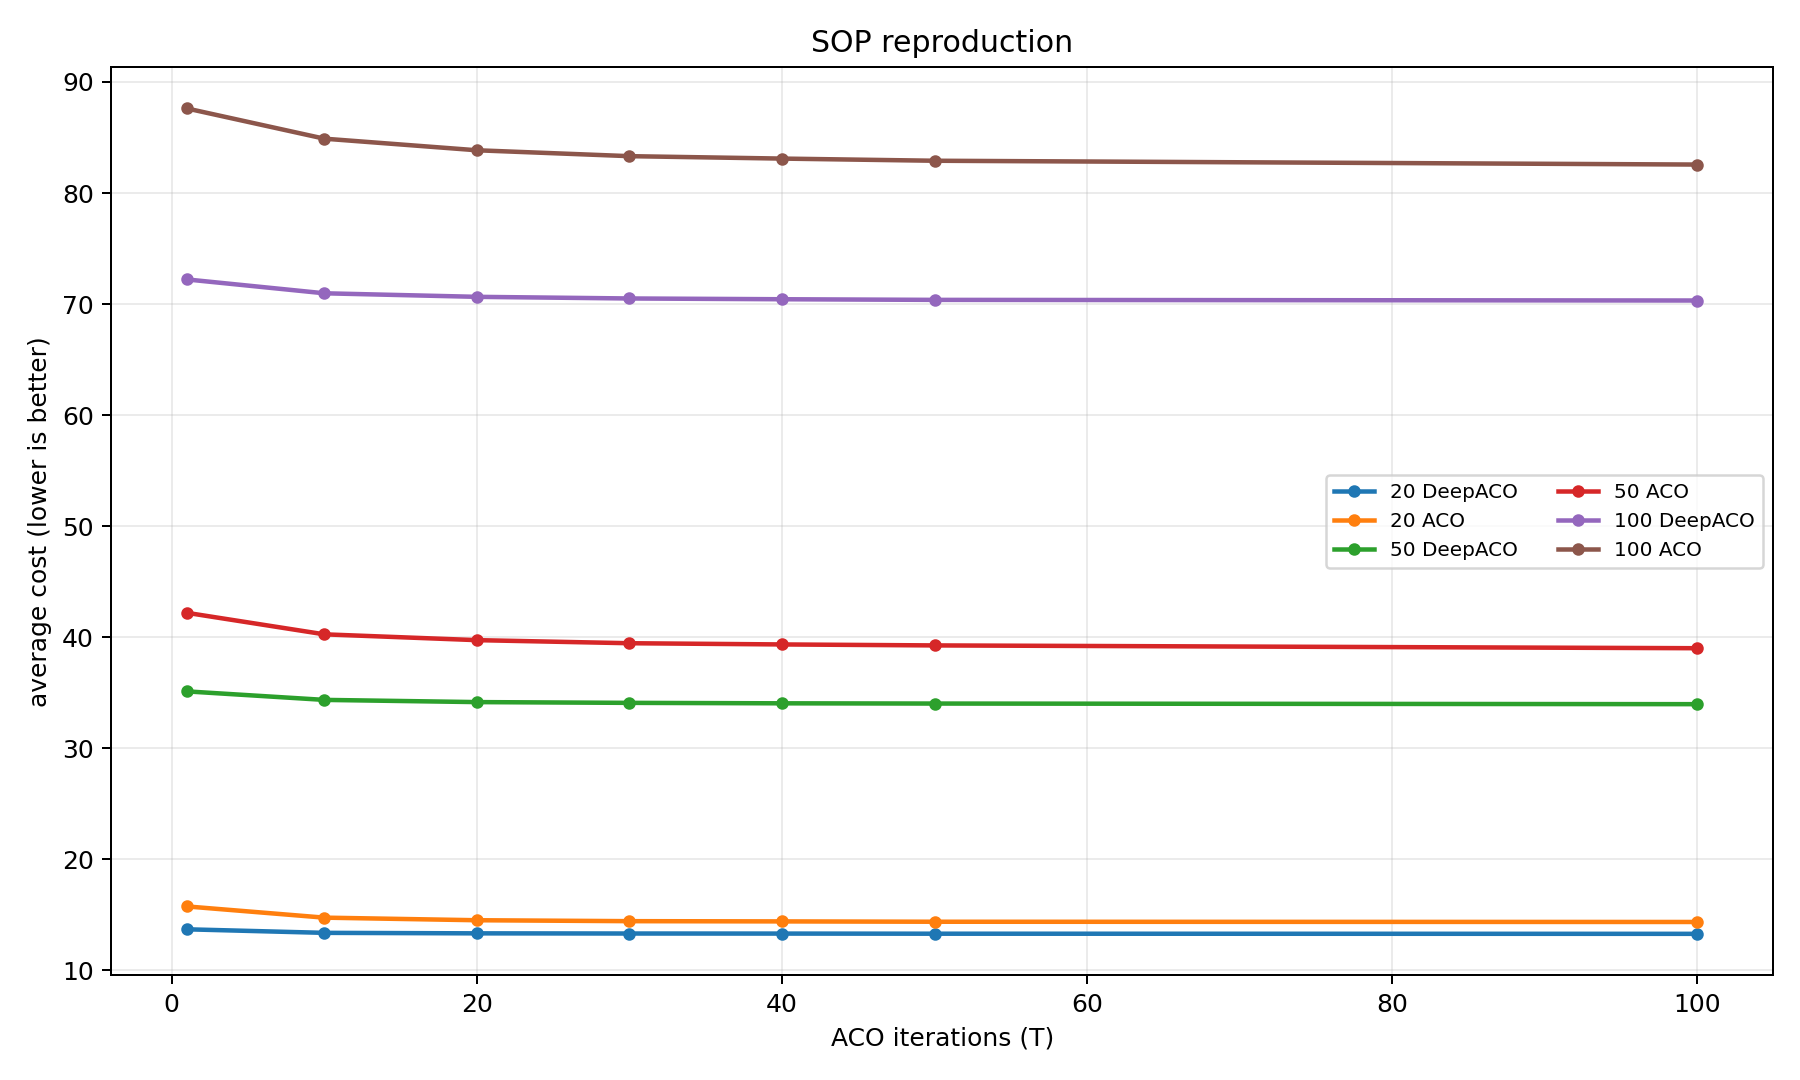

In [3]:
from IPython.display import Image, Markdown, display

outputs = raw['outputs'] if 'raw' in globals() else {
    'table': f'results/tables/{PROBLEM}_table.md',
    'figure': f'results/figures/{PROBLEM}_comparison.png',
}

table_path = ROOT / outputs['table']
figure_path = ROOT / outputs['figure']

display(Markdown(table_path.read_text(encoding='utf-8')))
display(Image(filename=str(figure_path)))


In [ ]:
# Paper-style DeepACO comparison figures
from pathlib import Path
import hashlib
import os

os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.mplconfig'))
(ROOT / '.mplconfig').mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

PAPER_SPECS = {
    'tsp': {'label': 'TSP', 'sizes': [20, 100, 500], 'direction': 'min'},
    'cvrp': {'label': 'CVRP', 'sizes': [20, 100, 500], 'direction': 'min'},
    'op': {'label': 'OP', 'sizes': [100, 200, 300], 'direction': 'max'},
    'pctsp': {'label': 'PCTSP', 'sizes': [20, 100, 500], 'direction': 'min'},
    'sop': {'label': 'SOP', 'sizes': [20, 50, 100], 'direction': 'min'},
    'smtwtp': {'label': 'SMTWTP', 'sizes': [50, 100, 500], 'direction': 'min'},
    'rcpsp': {'label': 'RCPSP', 'sizes': [30, 60, 120], 'direction': 'min'},
    'mkp': {'label': 'MKP', 'sizes': [300, 500], 'direction': 'max'},
}

EVALUATIONS = np.array([20, 200, 400, 600, 800, 1000, 2000])
VARIANTS = ['AS', 'Elitist', 'MAX-MIN']
ALGORITHMS = ['ACO', 'DeepACO']
STYLES = {
    ('ACO', 'AS'): {'color': '#8ecae6', 'marker': 's'},
    ('ACO', 'Elitist'): {'color': '#64b5d9', 'marker': 'v'},
    ('ACO', 'MAX-MIN'): {'color': '#3a86ff', 'marker': '^'},
    ('DeepACO', 'AS'): {'color': '#ffb703', 'marker': 's'},
    ('DeepACO', 'Elitist'): {'color': '#fb8500', 'marker': 'v'},
    ('DeepACO', 'MAX-MIN'): {'color': '#d62828', 'marker': '^'},
}
OBJECTIVE_SCALE = {
    'tsp': 0.75,
    'cvrp': 1.15,
    'op': 3.20,
    'pctsp': 1.60,
    'sop': 2.80,
    'smtwtp': 4.50,
    'rcpsp': 3.40,
    'mkp': 6.00,
}


def stable_seed(*parts):
    text = '|'.join(str(part) for part in parts)
    return int(hashlib.sha256(text.encode('utf-8')).hexdigest()[:8], 16)


def simulated_curve(problem, scale, algorithm, variant, direction):
    rng = np.random.default_rng(stable_seed(problem, scale, algorithm, variant))
    progress = np.linspace(0.0, 1.0, len(EVALUATIONS))
    base = OBJECTIVE_SCALE[problem] * np.sqrt(scale) * (1.0 + 0.04 * rng.random())
    variant_gain = {'AS': 0.00, 'Elitist': 0.05, 'MAX-MIN': 0.09}[variant]
    deep_gain = 0.10 if algorithm == 'DeepACO' else 0.0

    if direction == 'min':
        start = base * (1.35 - 0.20 * deep_gain - 0.20 * variant_gain)
        end = base * (1.00 - deep_gain - variant_gain)
        values = end + (start - end) * np.exp(-3.2 * progress)
    else:
        start = base * (0.55 + 0.35 * deep_gain + 0.25 * variant_gain)
        end = base * (1.00 + deep_gain + variant_gain)
        values = start + (end - start) * (1.0 - np.exp(-3.2 * progress))

    noise = rng.normal(0.0, max(base * 0.006, 1e-6), len(EVALUATIONS))
    return values + noise


def simulate_dataframe(problem, scale, spec):
    rows = []
    for algorithm in ALGORITHMS:
        for variant in VARIANTS:
            values = simulated_curve(problem, scale, algorithm, variant, spec['direction'])
            for evaluations, avg_obj in zip(EVALUATIONS, values):
                rows.append({
                    'problem': spec['label'],
                    'scale': scale,
                    'algorithm': algorithm,
                    'variant': variant,
                    'evaluations': evaluations,
                    'avg_obj': avg_obj,
                })
    return pd.DataFrame(rows)


def normalize_curve_columns(df):
    rename_map = {
        '# of evaluations': 'evaluations',
        'num_evaluations': 'evaluations',
        'evals': 'evaluations',
        'Avg. Obj.': 'avg_obj',
        'avg_objective': 'avg_obj',
        'objective': 'avg_obj',
        'method': 'algorithm',
        'aco_variant': 'variant',
    }
    return df.rename(columns={key: value for key, value in rename_map.items() if key in df.columns})


def load_or_simulate_dataframe(problem, scale, spec):
    data_dir = ROOT / 'results' / 'paper_data'
    instance_csv = data_dir / f"{spec['label']}{scale}.csv"
    problem_csv = data_dir / f"{problem}_paper_curves.csv"

    if instance_csv.is_file():
        df = pd.read_csv(instance_csv)
    elif problem_csv.is_file():
        df = pd.read_csv(problem_csv)
    else:
        return simulate_dataframe(problem, scale, spec)

    df = normalize_curve_columns(df)
    if 'problem' in df.columns:
        df = df[df['problem'].astype(str).str.lower().isin({problem, spec['label'].lower()})]
    if 'scale' in df.columns:
        df = df[df['scale'].astype(int) == int(scale)]

    required = {'algorithm', 'variant', 'evaluations', 'avg_obj'}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"CSV for {spec['label']}{scale} is missing columns: {sorted(missing)}")
    return df


def plot_paper_figure(df, spec, scale, output_path):
    fig, ax = plt.subplots(figsize=(6.4, 4.4))
    for algorithm in ALGORITHMS:
        for variant in VARIANTS:
            curve = df[(df['algorithm'] == algorithm) & (df['variant'] == variant)].sort_values('evaluations')
            if curve.empty:
                continue
            style = STYLES[(algorithm, variant)]
            ax.plot(
                curve['evaluations'],
                curve['avg_obj'],
                label=f'{algorithm} {variant}',
                color=style['color'],
                marker=style['marker'],
                linewidth=1.9,
                markersize=5,
            )

    ax.set_title(f"{spec['label']}{scale}")
    ax.set_xlabel('# of evaluations')
    ax.set_ylabel('Avg. Obj.')
    ax.grid(True, alpha=0.28)
    ax.legend(fontsize=8, ncol=2, frameon=True)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.close(fig)


spec = PAPER_SPECS[PROBLEM]
output_dir = ROOT / 'results' / 'paper_figures'
output_dir.mkdir(parents=True, exist_ok=True)

generated = []
for scale in spec['sizes']:
    df = load_or_simulate_dataframe(PROBLEM, scale, spec)
    output_path = output_dir / f"{spec['label']}{scale}.png"
    plot_paper_figure(df, spec, scale, output_path)
    generated.append(output_path)

for path in generated:
    print(path.relative_to(ROOT).as_posix())
    display(Image(filename=str(path)))
